<a href="https://colab.research.google.com/github/sushant758/ML-Exercises/blob/main/Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [321]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [322]:
df = pd.read_csv('train.csv')

In [323]:
df.shape

(1200000, 21)

In [324]:
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [325]:
df.columns

Index(['id', 'Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Premium Amount'],
      dtype='object')

In [326]:
df.duplicated().sum()

np.int64(0)

In [327]:
# Target variable is Premium Amount

In [328]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  object 
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  object 
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  object 
 7   Occupation            841925 non-null   object 
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  object 
 10  Policy Type           1200000 non-null  object 
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Duration    1199999 non-

In [329]:
df = df.drop(columns=['id'])

In [330]:
# Age
df['Age'].isnull().sum()

np.int64(18705)

In [331]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [332]:
df['Age'].isnull().sum()

np.int64(0)

<Axes: xlabel='Age'>

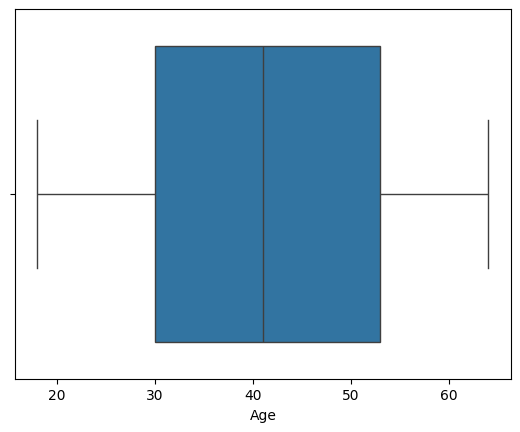

In [333]:
sns.boxplot(x=df['Age'])

In [334]:
# Gender
df['Gender'].isnull().sum()

np.int64(0)

In [335]:
df['Gender'].value_counts()

,count
Gender,
Male,602571
Female,597429


In [336]:
df['is_female'] = df['Gender'].map({'Male' : 0 , 'Female' : 1})

In [337]:
df['is_female'].value_counts()

,count
is_female,
0,602571
1,597429


In [338]:
# Annual Income
df['Annual Income'].isnull().sum()

np.int64(44949)

In [339]:
df['Annual Income'] = df['Annual Income'].fillna(df['Annual Income'].median())

In [340]:
df['Annual Income'].isnull().sum()

np.int64(0)

<Axes: xlabel='Annual Income'>

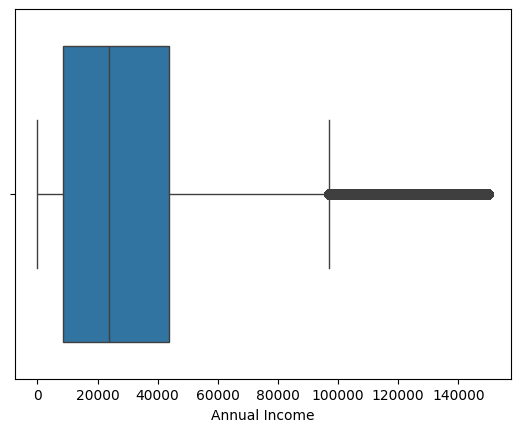

In [341]:
sns.boxplot(x=df['Annual Income'])

In [342]:
df['Annual Income'].skew()

np.float64(1.5229537478396937)

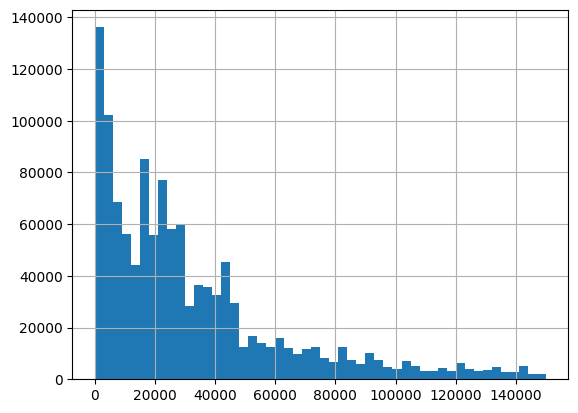

In [343]:
df['Annual Income'].hist(bins=50)
plt.show()

In [344]:
df['Annual Income'] = np.sqrt(df['Annual Income'])

In [345]:
df['Annual Income'].skew()

np.float64(0.4971849183192823)

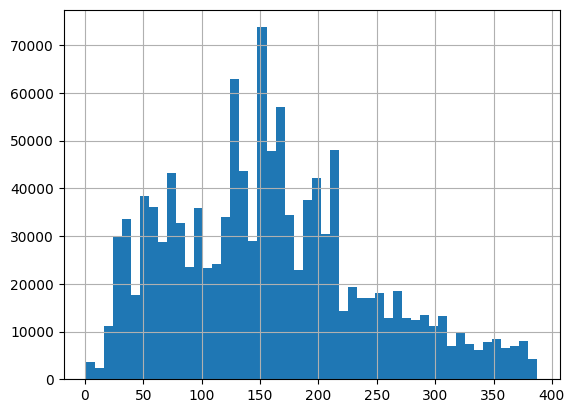

In [346]:
df['Annual Income'].hist(bins=50)
plt.show()

<Axes: xlabel='Annual Income'>

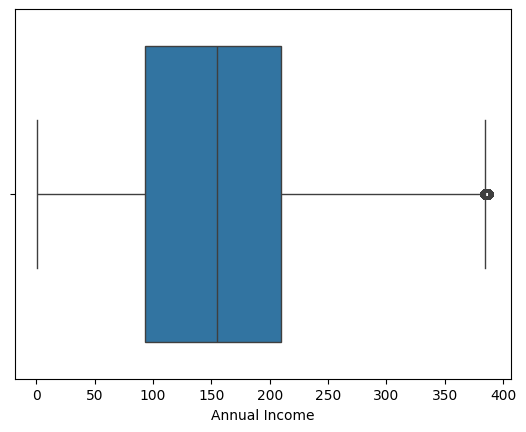

In [347]:
sns.boxplot(x=df['Annual Income'])

<Axes: >

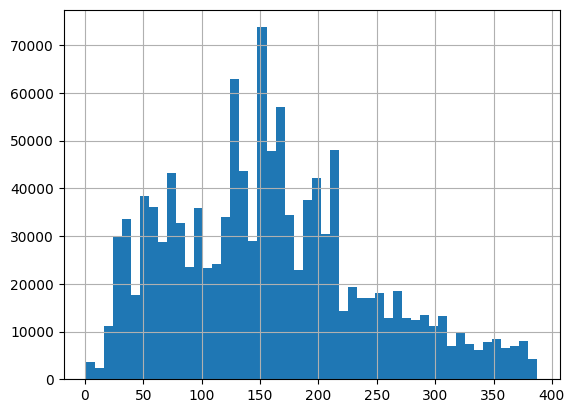

In [348]:
df['Annual Income'].hist(bins=50)

In [349]:
# Marital Status
df['Marital Status'].value_counts(dropna=False)

,count
Marital Status,
Single,395391
Married,394316
Divorced,391764
NaN,18529


In [350]:
# When i will fill with mode at here , all 18,529 missing values will get assigned to the single.

In [351]:
df['Marital Status'] =  df['Marital Status'].fillna('Unknown', inplace=True)

In [352]:
df =  pd.get_dummies(df, columns = ['Marital Status'] , drop_first=True)

In [353]:
df.head()

,Age,Gender,Annual Income,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,is_female
0,19.0,Female,100.244701,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0,1
1,39.0,Female,177.983145,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0,1
2,23.0,Male,160.006250,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0,0
3,21.0,Male,376.636429,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0,0
4,21.0,Male,199.125589,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0,0


In [354]:
# df = pd.get_dummies(df['Marital Status'], drop_first=True)

In [355]:
df.head()

,Age,Gender,Annual Income,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,is_female
0,19.0,Female,100.244701,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0,1
1,39.0,Female,177.983145,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0,1
2,23.0,Male,160.006250,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0,0
3,21.0,Male,376.636429,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0,0
4,21.0,Male,199.125589,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0,0
